## **Build a ReAct Agent**

You're a software engineer on a mission: build an AI agent that doesn't just respond—it thinks. In this lab, you'll step into the role of an AI architect, designing a smart assistant that solves tough problems by reasoning through them and taking purposeful actions.

Using the ReAct (Reasoning + Acting) framework, you'll teach your agent to think step by step, consult tools like search engines or calculators, and adapt on the fly. It’s not just about answers—it’s about how the agent gets there.

By the end of the lab, your AI will face a mystery that can’t be solved with knowledge alone. It will need logic, resourcefulness, and the ability to act—just like you, the engineer who built it.

## What is ReAct?

**ReAct** stands for **Reasoning + Acting**. It's a framework that combines:

1. **Reasoning**: The agent thinks through problems step by step, maintaining an internal dialogue about what it needs to do.
2. **Acting**: The agent can use external tools (search engines, calculators, APIs) to gather information or perform actions.
3. **Observing**: The agent processes the results from its actions and incorporates them into its reasoning.

This creates a powerful loop: **Think → Act → Observe → Think → Act → ...**

### Why ReAct Matters

Traditional language models are limited by their training data cutoff and can't access real-time information. ReAct agents overcome this by:
- Accessing current information through web searches
- Performing calculations with specialized tools
- Breaking down complex problems into manageable steps
- Adapting their approach based on intermediate results


In [2]:
from langchain_community.tools.tavily_search import TavilySearchResults
import os
import dotenv

C:\Users\Vish\AppData\Local\Temp\ipykernel_10668\2498070253.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [3]:
dotenv.load_dotenv()
taily_key = os.getenv("travily_api_key")
groq_key = os.getenv("groq_api")

In [4]:
tavily_search = TavilySearchResults(tavily_api_key=taily_key)

C:\Users\Vish\AppData\Local\Temp\ipykernel_10668\1159681569.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search = TavilySearchResults(tavily_api_key=taily_key)


In [5]:
from langchain_groq import ChatGroq

d:\Projects\langgraph-explore\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=groq_key
)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.13'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001AADE602190>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001AA80192850>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [7]:
tavily_search.invoke("What is the weather in tokoyo now?")

[{'title': 'What will the weather be like in Tokyo on 17 July 2026',
  'url': 'https://www.metcheck.com/WEATHER/dayforecast.asp?location=Tokyo&locationID=948135&lat=35.6895&lon=139.69171&dateFor=17%2F07%2F2026',
  'content': '| 17:00 | 27°c | 29°c | 21% | 0.5mm | 100% |  | 3kph | 10kph | 90% | 0 |  |\n| 18:00 | 26°c | 27°c | 17% | 0.5mm | 100% |  | 3kph | 10kph | 95% | 0 |  |\n| 19:00 | 25°c | 25°c | 12% | 0.5mm | 97% |  | 3kph | 14kph | 97% | 0 |  |\n| 20:00 | 24°c | 24°c | 15% | 0.3mm | 98% |  | 7kph | 17kph | 98% | 0 |  |\n| 21:00 | 24°c | 23°c | 20% | 0.3mm | 100% |  | 3kph | 14kph | 98% | 0 |  |\n| 22:00 | 24°c | 23°c | 23% | 0.6mm | 72% |  | 3kph | 14kph | 97% | 0 |  |\n| 23:00 | 24°c | 23°c | 25% | 0.1mm | 82% |  | 3kph | 14kph | 97% | 0 |  |\n|  |  |  |  |  |  |  |  |  |  |  |  | [...] |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |\n ---  ---  ---  ---  ---  ---  --- \n| Friday 17 July☀ ▲ 04:37    18:56  ▼ ☼ | | | | | | | | | | | | | | |\n|  | | | | | | | | | | | | | | |\n| Tim

In [8]:
from langchain_core.tools import tool

In [9]:
@tool
def clothing_recommendation(weather:str) -> str:
    
    """Returns clothing recommendation based on the given weather condition
    
    This function examines the input string for specific keywords or temperature indicators 
    (e.g., "snow", "freezing", "rain", "85°F") to suggest appropriate attire. It handles 
    common weather conditions like snow, rain, heat, and cold by providing simple and practical 
    clothing advice.
    
    Args:
    - weather (str): A brief description of the weather (e.g., "Overcast, 64.9°F")
    
    Return:
    - str: A string with clothing recommendations suitable for the weather
    """
    
    weather = weather.lower()
    
    if "snow" in weather or "freezing" in weather:
        return "Wear a heavy coat, gloves, and boots."
    elif "rain" in weather or "wet" in weather:
        return "Bring a raincoat and waterproof shoes."
    elif "hot" in weather or "85" in weather:
        return "T-shirt, shorts, and sunscreen recommended."
    elif "cold" in weather or "50" in weather:
        return "Wear a warm jacket or sweater."
    else:
        return "A light jacket should be fine."


In [24]:
@tool
def search_tool(query: str) -> str:
    """
    Search the web for current information using Tavily.

    Args:
        query: The search query.

    Returns:
        Search results as text.
    """

    results = tavily_search.invoke(query)
    
    formatted_results = "\n\n".join(
        [
            f"Title: {item['title']}\n"
            f"Content: {item['content']}\n"
            f"Source: {item['url']}"
            for item in results
        ]
    )

    return formatted_results

In [25]:
tools = [search_tool, clothing_recommendation]

tools_map = {
    tool.name:tool for tool in tools
}

tools_map

{'search_tool': StructuredTool(name='search_tool', description='Search the web for current information using Tavily.\n\nArgs:\n    query: The search query.\n\nReturns:\n    Search results as text.', args_schema=<class 'langchain_core.utils.pydantic.search_tool'>, func=<function search_tool at 0x000001AA841BC4A0>),
 'clothing_recommendation': StructuredTool(name='clothing_recommendation', description='Returns clothing recommendation based on the given weather condition\n\n    This function examines the input string for specific keywords or temperature indicators \n    (e.g., "snow", "freezing", "rain", "85°F") to suggest appropriate attire. It handles \n    common weather conditions like snow, rain, heat, and cold by providing simple and practical \n    clothing advice.\n\n    Args:\n    - weather (str): A brief description of the weather (e.g., "Overcast, 64.9°F")\n\n    Return:\n    - str: A string with clothing recommendations suitable for the weather', args_schema=<class 'langchain_

In [26]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import HumanMessage, AIMessage,BaseMessage,SystemMessage,ToolMessage

In [27]:
chat_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are a helpful assistant that think step-by-step and use tools when needed.
    
            when responding to query:
            1. First, think about what information you need.
            2. Use available tools if you need current data or specific capabilities
            3. Provide clear, helpful response based on your reasoning and any tool results
            """
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

In [28]:
llm_chain = chat_prompt | llm.bind_tools(tools) 

In [29]:
from typing import TypedDict, Annotated, Sequence
from langgraph.graph.message import add_messages

In [30]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [31]:
def model_call(state:AgentState):
    
    results = llm_chain.invoke({
        "messages": state['messages']
    })
    
    return {
        "messages": [results]
    }
    

In [32]:
def tool_call(state:AgentState):
    
    last_ai_message = state['messages'][-1]
    tools_call = last_ai_message.tool_calls
    
    results = []
    
    for tool_use in tools_call:
        tool_result = tools_map[tool_use['name']].invoke(tool_use['args'])
        results.append(
            ToolMessage(
                content=tool_result,
                name=tool_use['name'],
                tool_call_id = tool_use["id"]
            )
        )
    
    return {
        "messages": results
    }

In [33]:
from langgraph.graph import END,StateGraph

In [34]:
def should_continue(state:AgentState):
    
    last_ai_message = state['messages'][-1]
    
    if not last_ai_message.tool_calls:
        return "end"
    
    else:
        return "continue"

In [35]:
graph = StateGraph(AgentState)

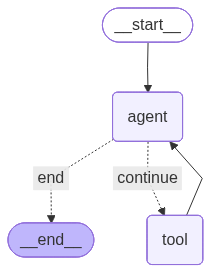

In [36]:
graph.add_node("agent", model_call)
graph.add_node("tool", tool_call)

graph.add_edge("tool","agent")
graph.add_conditional_edges("agent", should_continue,{
    "end":END,
    "continue": "tool"
})

graph.set_entry_point("agent")
app = graph.compile()
app

In [37]:
response = app.invoke({
    "messages": [HumanMessage(content="What is the weather condition in tokoyo now and recommend me some cloths to wear?")]
})

In [38]:
response

{'messages': [HumanMessage(content='What is the weather condition in tokoyo now and recommend me some cloths to wear?', additional_kwargs={}, response_metadata={}, id='910ed4bf-8942-4172-bcf7-469cbe1aafaf'),
  AIMessage(content="To find the current weather condition in Tokyo and get a clothing recommendation, I'll use the search tool to look up the current weather in Tokyo.\n\n", additional_kwargs={'tool_calls': [{'id': 's57d3aya7', 'function': {'arguments': '{"query":"current weather in Tokyo today"}', 'name': 'search_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 638, 'total_tokens': 699, 'completion_time': 0.103027822, 'completion_tokens_details': None, 'prompt_time': 0.038515782, 'prompt_tokens_details': None, 'queue_time': 0.049322977, 'total_time': 0.141543604}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'mode

In [39]:
def print_stream(stream):
    """Helper function for formatting the stream nicely."""
    
    for s in stream:
        message = s['messages'][-1]
        
        if isinstance(message,tuple):
            print(message)
        else:
            message.pretty_print()

In [40]:
inputs = {"messages": [HumanMessage(content="What's the weather like in Zurich, and what should I wear based on the temperature?")]}

In [41]:
print_stream(app.stream(inputs,stream_mode="values"))

================================ Human Message =================================

What's the weather like in Zurich, and what should I wear based on the temperature?
================================== Ai Message ==================================

To find the current weather in Zurich, I'll first try to find an up-to-date source of information.
Tool Calls:
  search_tool (6qjfnmg47)
 Call ID: 6qjfnmg47
  Args:
    query: Zurich weather
================================= Tool Message =================================
Name: search_tool

Title: Zurich weather in July 2026
Content: weather25.com 

United States England Australia Canada

°F °C

Weather in July 2026

Remove from your favorite locations Add to my locations

Share

1. Home
2. Europe
3. weather in SwitzerlandSwitzerland
4. Zurich
5. July

Location was added to My Locations

Location was removed from My Locations

# Zurich weather in July 2026

Click on a day for an hourly weather forecast

Jul 12

Sunny

0 mm

29° / 13°Jul 13

Pa

In [44]:
input_2 = {
    "messages": [HumanMessage(content="What is the weather condition in tokoyo now and recommend me some cloths to wear?")]
}

In [46]:
print_stream(app.stream(input_2, stream_mode="values"))

================================ Human Message =================================

What is the weather condition in tokoyo now and recommend me some cloths to wear?
================================== Ai Message ==================================
Tool Calls:
  search_tool (ge06x2re7)
 Call ID: ge06x2re7
  Args:
    query: Tokyo weather now
  clothing_recommendation (darrsbcwt)
 Call ID: darrsbcwt
  Args:
    weather: search results from previous function call
================================= Tool Message =================================
Name: clothing_recommendation

A light jacket should be fine.
================================== Ai Message ==================================
Tool Calls:
  clothing_recommendation (b6pc00xcm)
 Call ID: b6pc00xcm
  Args:
    weather: Clear, 25-28°C, 67-82% humidity
================================= Tool Message =================================
Name: clothing_recommendation

A light jacket should be fine.
================================== Ai Message ==